<!-- Projeto Desenvolvido na Data Science Academy - www.datascienceacademy.com.br -->
# <font color='blue'>Data Science Academy</font>
## <font color='blue'>Engenharia Financeira com Inteligência Artificial</font>
## <font color='blue'>Projeto 1</font>
## <font color='blue'>Inteligência Artificial Para Prever o Preço de Ativos Financeiros</font>

## Instalando e Carregando Pacotes

In [1]:
# Para atualizar um pacote, execute o comando abaixo no terminal ou prompt de comando:
# pip install -U nome_pacote

# Para instalar a versão exata de um pacote, execute o comando abaixo no terminal ou prompt de comando:
# pip install nome_pacote==versão_desejada

# Depois de instalar ou atualizar o pacote, reinicie o jupyter notebook.

# Instala o pacote watermark. 
# Esse pacote é usado para gravar as versões de outros pacotes usados neste jupyter notebook.
!pip install -q -U watermark

https://finance.yahoo.com/

https://pypi.org/project/yfinance/

In [2]:
!pip install -q yfinance

In [3]:
# Imports
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

In [4]:
%reload_ext watermark
%watermark -a "Data Science Academy"

Author: Data Science Academy



## Extração dos Dadoa via API

In [5]:
# Extrai os dados via API
dados = yf.Ticker("^GSPC")

**"^GSPC"**: é o símbolo (ticker) que representa o índice S&P 500 no Yahoo Finance. O S&P 500 é um índice que reflete a performance de 500 das maiores empresas listadas nas bolsas de valores dos Estados Unidos, sendo amplamente considerado como um dos melhores indicadores da performance do mercado de ações.

https://finance.yahoo.com/quote/%5EGSPC/

Você pode customizar o projeto com outros Tickers:

https://stockanalysis.com/list/nasdaq-stocks/

In [6]:
type(dados)

yfinance.ticker.Ticker

In [7]:
# Obtemos o histórico de preços do índice S&P 500 ao longo do tempo máximo disponível
df_dsa = dados.history(period = "max")

## Análise Exploratória dos Dados

In [8]:
# Shape
df_dsa.shape

(24481, 7)

In [9]:
# Dados extraídos
df_dsa.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0


In [10]:
# Dados extraídos
df_dsa.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-06-11 00:00:00-04:00,6049.379883,6059.399902,6002.319824,6022.240234,5111550000,0.0,0.0
2025-06-12 00:00:00-04:00,6009.899902,6045.430176,6003.879883,6045.259766,4669500000,0.0,0.0
2025-06-13 00:00:00-04:00,6000.560059,6026.160156,5963.209961,5976.970215,5258910000,0.0,0.0
2025-06-16 00:00:00-04:00,6004.000000,6050.830078,6004.000000,6033.109863,5111710000,0.0,0.0
2025-06-17 00:00:00-04:00,6012.149902,6023.250000,5974.799805,5982.720215,4955700000,0.0,0.0


**ATENÇÃO: Quando você executar o projeto seus dados serão diferentes, pois estamos extraindo todos os dados até a data de execução do projeto. O projeto irá funcionar da mesma forma, mas os resultados e conclusões poderão ser diferentes.**

In [11]:
# Índice
df_dsa.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2025-06-04 00:00:00-04:00', '2025-06-05 00:00:00-04:00',
               '2025-06-06 00:00:00-04:00', '2025-06-09 00:00:00-04:00',
               '2025-06-10 00:00:00-04:00', '2025-06-11 00:00:00-04:00',
               '2025-06-12 00:00:00-04:00', '2025-06-13 00:00:00-04:00',
               '2025-06-16 00:00:00-04:00', '2025-06-17 00:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=24481, freq=None)

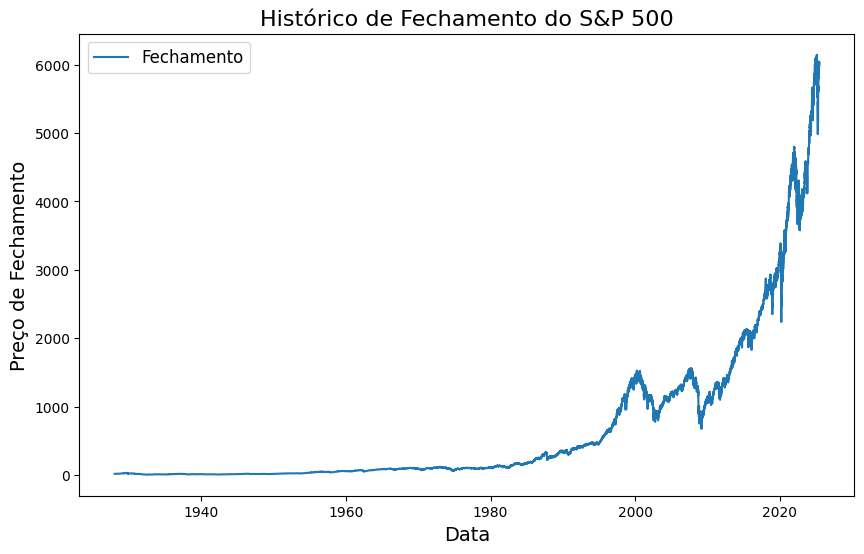

In [12]:
# Define o tamanho do gráfico
plt.figure(figsize = (10, 6))

# Cria o gráfico de linha para a coluna 'Close'
plt.plot(df_dsa.index, df_dsa['Close'], label = 'Fechamento') 

# Adiciona um título ao gráfico
plt.title('Histórico de Fechamento do S&P 500', fontsize = 16)

# Adiciona rótulos aos eixos
plt.xlabel('Data', fontsize = 14)
plt.ylabel('Preço de Fechamento', fontsize = 14)

# Mostra a legenda
# O parâmetro loc controla a posição da legenda. Ex: 'upper left', 'upper right', 'lower left', 'lower right'
plt.legend(loc = 'best', fontsize = 12)

# Mostra o gráfico
plt.show()

In [13]:
# Deleta as colunas que não serão usadas
del df_dsa["Dividends"]
del df_dsa["Stock Splits"]

In [14]:
df_dsa.head()

,Open,High,Low,Close,Volume
Date,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0


In [15]:
df_dsa.describe()

,Open,High,Low,Close,Volume
count,24481.000000,24481.000000,24481.000000,24481.000000,2.448100e+04
mean,682.154634,686.147702,677.918789,682.301534,9.383120e+08
std,1137.852542,1144.143986,1131.127908,1138.078248,1.649285e+09
min,4.400000,4.400000,4.400000,4.400000,0.000000e+00
25%,24.809999,24.809999,24.809999,24.809999,1.570000e+06
50%,102.970001,103.849998,102.160004,102.980003,2.117000e+07
75%,1068.089966,1075.959961,1060.589966,1068.760010,1.092700e+09
max,6134.500000,6147.430176,6111.149902,6144.149902,1.145623e+10


## Engenharia de Atributos

Vamos preparar a variável alvo.

In [16]:
df_dsa.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2025-06-11 00:00:00-04:00,6049.379883,6059.399902,6002.319824,6022.240234,5111550000
2025-06-12 00:00:00-04:00,6009.899902,6045.430176,6003.879883,6045.259766,4669500000
2025-06-13 00:00:00-04:00,6000.560059,6026.160156,5963.209961,5976.970215,5258910000
2025-06-16 00:00:00-04:00,6004.000000,6050.830078,6004.000000,6033.109863,5111710000
2025-06-17 00:00:00-04:00,6012.149902,6023.250000,5974.799805,5982.720215,4955700000


In [17]:
# Cria nova variável
df_dsa["Tomorrow"] = df_dsa["Close"].shift(-1)

A linha de código acima é usada para criar uma nova coluna no DataFrame df_dsa chamada "Tomorrow", que armazena os valores da coluna "Close" deslocados uma linha para cima. 

O método shift() é usado para deslocar os dados na coluna para cima ou para baixo. O argumento -1 indica que os dados devem ser deslocados uma linha para cima. Isso significa que cada valor na nova coluna "Tomorrow" será o valor de "Close" do próximo dia de negociação. Por exemplo, o valor de "Tomorrow" para o dia 1 de janeiro seria o valor de "Close" para o dia 2 de janeiro, e assim por diante. 

O último valor na coluna "Tomorrow" será NaN (Not a Number), pois não há um próximo dia para o último registro no DataFrame.

In [18]:
df_dsa

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2025-06-11 00:00:00-04:00,6049.379883,6059.399902,6002.319824,6022.240234,5111550000,6045.259766
2025-06-12 00:00:00-04:00,6009.899902,6045.430176,6003.879883,6045.259766,4669500000,5976.970215
2025-06-13 00:00:00-04:00,6000.560059,6026.160156,5963.209961,5976.970215,5258910000,6033.109863


In [19]:
# Filtra os dados a partir de 1990
df_dsa = df_dsa.loc["1990-01-01":].copy()

O método loc é usado para acessar um grupo de linhas e colunas por rótulos ou uma matriz booleana no DataFrame. 

Neste caso, "1990-01-01": especifica um intervalo de datas a partir de 1º de janeiro de 1990 até o final do conjunto de dados. O uso do : sem especificar uma data de término indica que a seleção deve incluir todas as linhas a partir da data de início até a última linha disponível no DataFrame. O DataFrame df_dsa precisa ter um índice de tipo DateTime para que essa operação de filtragem baseada em data funcione corretamente.

.copy(): Este método cria uma cópia profunda do DataFrame resultante da operação de filtragem. Sem .copy(), a variável df_dsa apontaria para um subconjunto do DataFrame original, mantendo uma ligação com o DataFrame original. Isso poderia gerar erros em algumas operações devido a tentativas de modificar um recorte de um DataFrame sem criar uma cópia explicitamente. Usar .copy() garante que as modificações feitas na cópia não afetarão o DataFrame original e vice-versa.

In [20]:
df_dsa

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995
...,...,...,...,...,...,...
2025-06-11 00:00:00-04:00,6049.379883,6059.399902,6002.319824,6022.240234,5111550000,6045.259766
2025-06-12 00:00:00-04:00,6009.899902,6045.430176,6003.879883,6045.259766,4669500000,5976.970215
2025-06-13 00:00:00-04:00,6000.560059,6026.160156,5963.209961,5976.970215,5258910000,6033.109863


In [21]:
# Drop de valores NA
df_dsa = df_dsa.dropna()

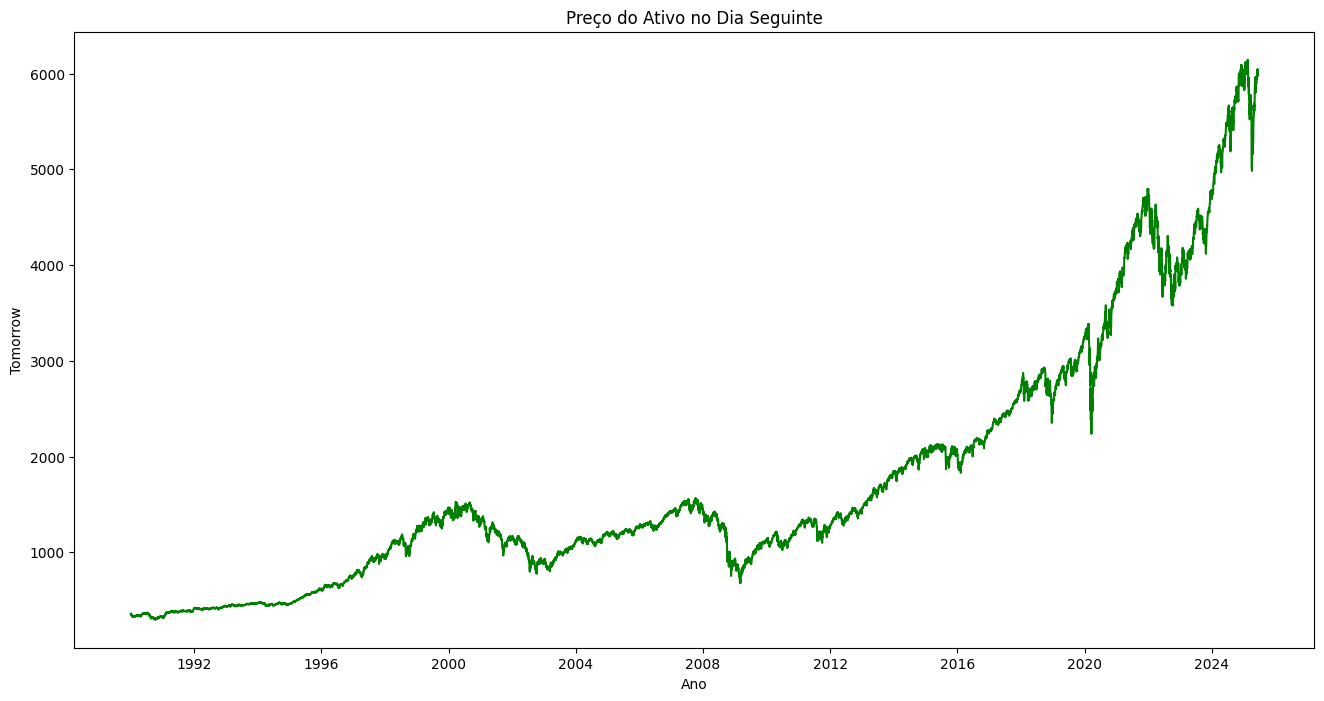

In [22]:
# Plot
plt.figure(figsize = (16,8))
plt.title('Preço do Ativo no Dia Seguinte')
plt.xlabel('Ano')
plt.ylabel('Tomorrow')
plt.plot(df_dsa['Tomorrow'], color = 'green')
plt.show()

## Definindo Variáveis de Entrada e Saída

In [23]:
# Variáveis de entrada
x = df_dsa[['Open', 'High', 'Low', 'Close', 'Volume']]

In [24]:
# Variável de saída (valor de Close do dia seguinte)
y = df_dsa['Tomorrow']

In [25]:
x

,Open,High,Low,Close,Volume
Date,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000
...,...,...,...,...,...
2025-06-10 00:00:00-04:00,6009.910156,6043.009766,6000.279785,6038.810059,4882880000
2025-06-11 00:00:00-04:00,6049.379883,6059.399902,6002.319824,6022.240234,5111550000
2025-06-12 00:00:00-04:00,6009.899902,6045.430176,6003.879883,6045.259766,4669500000


In [26]:
y

Date
1990-01-02 00:00:00-05:00     358.760010
1990-01-03 00:00:00-05:00     355.670013
1990-01-04 00:00:00-05:00     352.200012
1990-01-05 00:00:00-05:00     353.790009
1990-01-08 00:00:00-05:00     349.619995
                                ...     
2025-06-10 00:00:00-04:00    6022.240234
2025-06-11 00:00:00-04:00    6045.259766
2025-06-12 00:00:00-04:00    5976.970215
2025-06-13 00:00:00-04:00    6033.109863
2025-06-16 00:00:00-04:00    5982.720215
Name: Tomorrow, Length: 8930, dtype: float64

Ficou claro por que removemos o valor NaN da última linha da série?

## Pré-Processamento dos Dados

In [27]:
# Separa os dados em amostra de treino e teste
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [28]:
# Cria o padronizador
scaler = StandardScaler()

In [29]:
# Treina o padronizador
scaler.fit(x_treino)

,copy,True
,with_mean,True
,with_std,True


In [30]:
# Aplica o padronizador
x_treino_scaled = scaler.transform(x_treino)

In [31]:
x_treino_scaled

array([[ 0.81185379,  0.80391971,  0.82124022,  0.80958803,  0.38683701],
       [ 0.5651587 ,  0.55459973,  0.56599673,  0.56283281,  0.51860375],
       [-0.41577653, -0.42030828, -0.41936869, -0.42542846, -0.07122936],
       ...,
       [-0.30084955, -0.3035901 , -0.29886024, -0.30009518,  0.59367676],
       [-0.9808455 , -0.97989267, -0.97807585, -0.97748867, -1.21717323],
       [ 0.7615132 ,  0.76388567,  0.77308127,  0.77429371,  0.54920886]],
      shape=(7144, 5))

In [32]:
# Aplica o padronizador
x_teste_scaled = scaler.transform(x_teste)

In [33]:
x_teste_scaled

array([[ 2.17316987,  2.17726124,  2.19367617,  2.19503481,  0.70015985],
       [-0.29638246, -0.30065264, -0.30923738, -0.31499512, -1.04231082],
       [-0.28343776, -0.27909107, -0.28078436, -0.27737234, -0.83334249],
       ...,
       [-0.55943906, -0.56419041, -0.5832685 , -0.57027332, -0.92367213],
       [-0.17736889, -0.17289625, -0.17006377, -0.16629209,  0.0657886 ],
       [-0.87718903, -0.87859605, -0.8740515 , -0.87620231, -1.14083064]],
      shape=(1786, 5))

## Modelagem Preditiva

O modelo de regressão linear é usado para modelar a relação entre uma variável dependente (ou variável de resposta) e uma ou mais variáveis independentes (ou preditores). O objetivo é prever o valor da variável dependente com base nos valores das variáveis independentes, assumindo que a relação entre elas é linear. Existem dois tipos principais de regressão linear: simples e múltipla. Aqui usaremos regressão linear múltipla (quando temos mais de uma variável de entrada).

O ajuste do modelo de regressão linear envolve encontrar os valores dos coeficientes que minimizam a soma dos quadrados dos resíduos (diferença entre os valores observados e os valores previstos). Isso é comumente feito usando o método dos mínimos quadrados.

A qualidade do ajuste do modelo é frequentemente avaliada usando o coeficiente de determinação (R2), que mede a proporção da variância na variável dependente que é previsível a partir das variáveis independentes. Outras métricas, como o erro quadrático médio (MSE) e o erro quadrático médio da raiz (RMSE), também são usadas para avaliar o desempenho do modelo.

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

In [34]:
# Cria o modelo
modelo_dsa = LinearRegression()

In [35]:
# Treina o modelo
modelo_dsa.fit(x_treino_scaled, y_treino)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
modelo_dsa.coef_

array([-3.58585678e+01,  2.40016935e+02,  1.83277112e+02,  9.28034609e+02,
       -7.36716689e-01])

In [37]:
modelo_dsa.intercept_

np.float64(1738.6594175742428)

Fórmula da Regressão Linear Múltipla (para este modelo que criamos com 5 variáveis de entrada):

y = b0 + b1x1 + b2x2 + b3x3 + b4x4 + b5x5

In [38]:
# Previsões com o modelo
y_pred = modelo_dsa.predict(x_teste_scaled)

In [39]:
y_pred

array([4621.91531628, 1328.89092148, 1373.57796536, ...,  987.85218657,
       1517.9795038 ,  586.73699121], shape=(1786,))

<!-- Projeto Desenvolvido na Data Science Academy - www.datascienceacademy.com.br -->
Leia o material no Capítulo 4 com a descrição das métricas.

In [40]:
print('MSE:', metrics.mean_squared_error(y_teste, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_teste, y_pred)))
print('MAE:', metrics.mean_absolute_error(y_teste, y_pred))
print('R2:', metrics.r2_score(y_teste, y_pred))

MSE: 578.6519215342561
RMSE: 24.05518491997632
MAE: 13.729142143841486
R2: 0.9996919151690623


In [41]:
# Cria um dataframe comparando valor real e valor previsto
df_resultado = pd.DataFrame({'Real':y_teste, 'Previsto':y_pred, 'Erro':abs(y_teste - y_pred)})

In [42]:
df_resultado

,Real,Previsto,Erro
Date,,,
2023-12-11 00:00:00-05:00,4643.700195,4621.915316,21.784879
1999-08-30 00:00:00-04:00,1320.410034,1328.890921,8.480887
1999-11-10 00:00:00-05:00,1381.459961,1373.577965,7.881996
2021-06-24 00:00:00-04:00,4280.700195,4268.495208,12.204987
2016-05-19 00:00:00-04:00,2052.320068,2038.906087,13.413981
...,...,...,...
2020-12-16 00:00:00-05:00,3722.479980,3702.976379,19.503602
2014-06-26 00:00:00-04:00,1960.959961,1956.429681,4.530280
1998-10-05 00:00:00-04:00,984.590027,987.852187,3.262160


Text(0.5, 1.0, 'Real x Previsto')

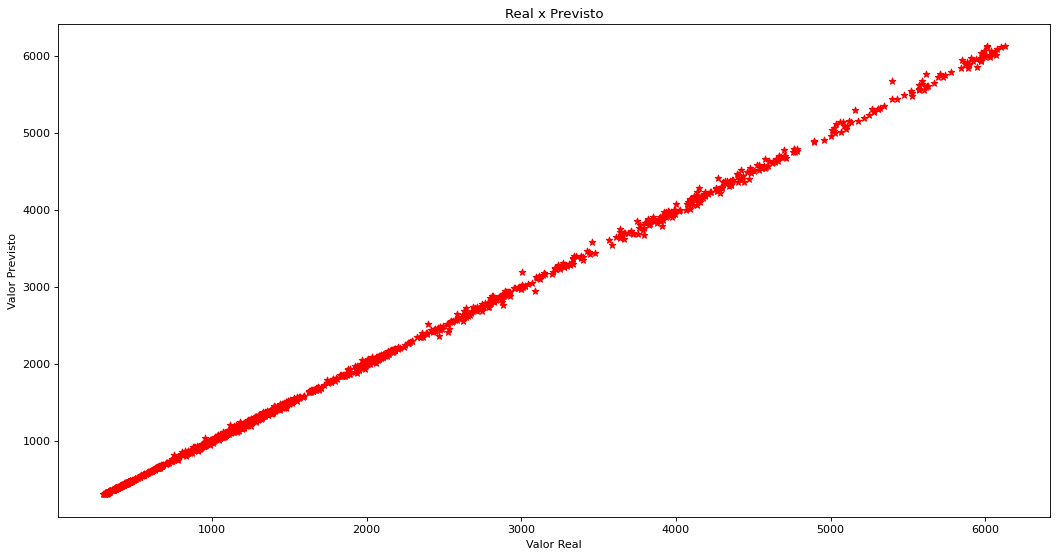

In [43]:
# Plot
plt.figure(figsize = (16,8), dpi = 80)
plt.scatter(y_teste, y_pred, color = 'red', marker = '*')
plt.xlabel('Valor Real')
plt.ylabel('Valor Previsto')
plt.title('Real x Previsto')

## Deploy e Uso do Modelo Para Prever o Valor de Ativos Financeiros

In [44]:
# Novos dados de entrada para previsão (por exemplo, valores dos indicadores ao final de uma segunda-feira)
novos_dados = pd.DataFrame({
    'Open': [3200.00],
    'High': [3250.00],
    'Low': [3180.00],
    'Close': [3225.00],
    'Volume': [5000000000]
})

In [45]:
# Padronizar os novos dados de entrada usando o mesmo scaler usado nos dados de treino
novos_dados_scaled = scaler.transform(novos_dados)

In [46]:
# Fazer a previsão usando o modelo
previsao_tomorrow = modelo_dsa.predict(novos_dados_scaled)

In [47]:
# Exibir a previsão (por exemplo, valor de fechamento da terça-feira)
print("Previsão do valor de fechamento para o próximo dia:", previsao_tomorrow[0])

Previsão do valor de fechamento para o próximo dia: 3224.7196806898414


> Vamos testar o modelo com dados que conhecemos:

No dia 16/06/2025, estes foram os valores de entrada: 6004.000000 6050.830078 6004.000000 6033.109863 5111710000

No dia 17/06/2025, este foi o valor de fechamento (Close): 5982.720215

Vamos ver se o modelo consegue prever esse valor do dia 17/06 (valor que já conhecemos)!

In [48]:
# Novos dados de entrada para previsão (por exemplo, valores dos indicadores ao final de uma segunda-feira)
novos_dados = pd.DataFrame({
    'Open': [6004.000000],
    'High': [6050.830078],
    'Low': [6004.000000],
    'Close': [6033.109863],
    'Volume': [5111710000]
})

In [49]:
# Padronizar os novos dados de entrada usando o mesmo scaler usado nos dados de treino
novos_dados_scaled = scaler.transform(novos_dados)

In [50]:
# Fazer a previsão usando o modelo
previsao_tomorrow = modelo_dsa.predict(novos_dados_scaled)

In [51]:
# Exibir a previsão (por exemplo, valor de fechamento da terça-feira)
print("Previsão do valor de fechamento para o próximo dia:", previsao_tomorrow[0])

Previsão do valor de fechamento para o próximo dia: 6036.318300611905


Margem de erro inferior a 1%. Projeto concluído com sucesso! Partimos para o próximo projeto.

In [52]:
%watermark -a "Data Science Academy"

Author: Data Science Academy



In [53]:
#%watermark -v -m

In [54]:
#%watermark --iversions

# Fim